In [53]:
%matplotlib inline
import jax.numpy as jnp
import matplotlib.pyplot as plt


# important imports 
import sys
sys.path.insert(0, "../")  
from TOOL_BOX_OF_FUNCTIONS.GAUSSIAN_PROCESSES_REGRESSION import GP_REGRESSION as GP 
from TOOL_BOX_OF_FUNCTIONS.METROPOLIS_1_CHAIN import METROPOLIS_1_CHAIN as MH

## Preparing the data and the model 

In [54]:
x = jnp.array([-2.17, 1.99, 0.57, -3.01, -1.16, 3.30, -4.85, -0.86]).reshape(-1, 1) # need to reshape to (n, 1)
print(f"Shape of X: {x.shape}")
y = jnp.array([0.88 ,0.46 ,-0.06, 0.98, 0.45,0.88 ,-0.66, 0.05])[:, None]  
print(f"Shape of y: {y.shape}")

# hyperparemeters
kappa = 0.7 
ell = 0.5 * jnp.sqrt(2)
sigma = 1/5


# Define the kernel 
kernel = GP.StationaryIsotropicKernel(kernel_fun=GP.squared_exponential, kappa=kappa, lengthscale=ell)

# define the model 
GP_ = GP.GaussianProcessRegression(X=x, y=y, kernel=kernel, kappa=kappa, lengthscale=ell, sigma=sigma)

Shape of X: (8, 1)
Shape of y: (8, 1)


## Question 2.2 Determine the analytical prior prediciton distribution $p(y^* |x^* = 1)$ for $y^* = y(x^*)$

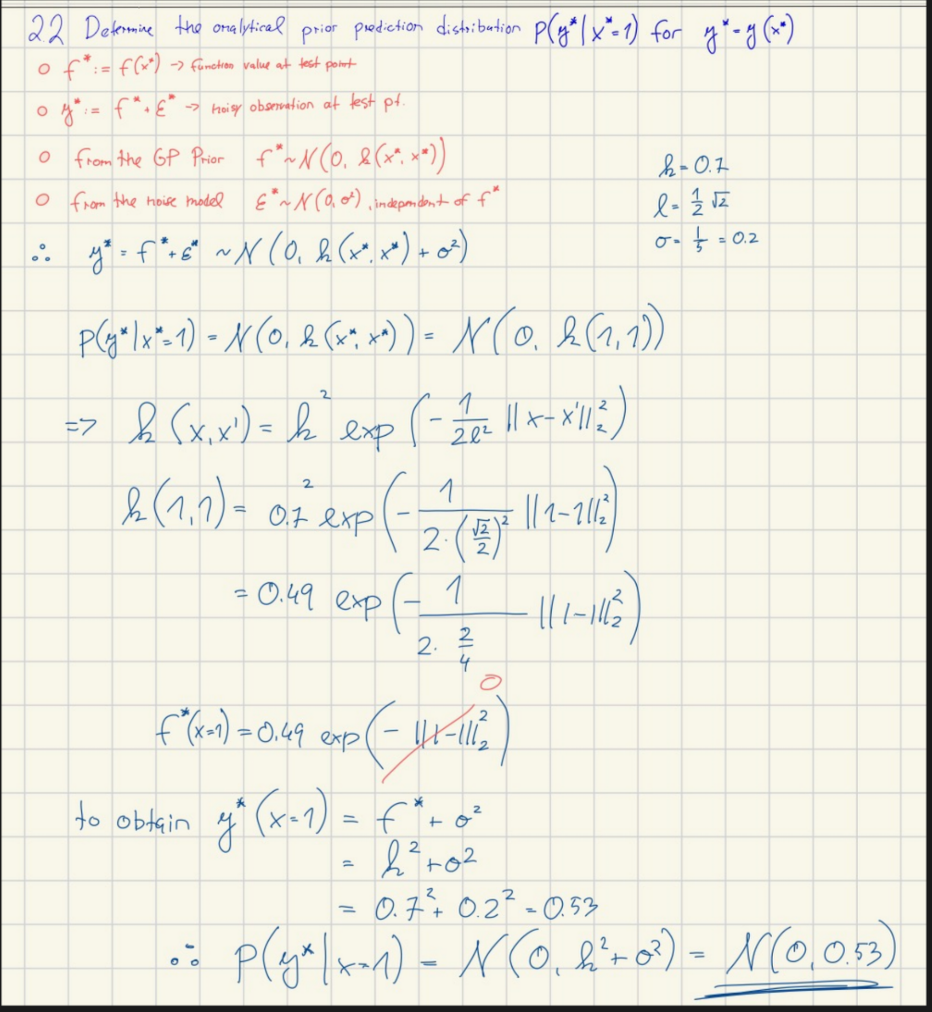

### Solution with the **Gaussian Process Regression Class** 

In [55]:

# x* = 1 # the prediction point 
x_star = jnp.array([1])

# get the mean and variance from the prior_predictive of y star 
prior_pred_y_mean, prior_pred_y_var = GP_.prior_predictive_y_star(Xstar=x_star)

# we can get the same by using the 
pror_pred_f_mean, prior_pred_f_mean = GP_.prior_predictive_f_star(Xstar=x_star)

print(f"Prior pred mean of y*: {prior_pred_y_mean.item():3.2f}")
print(f"Prior pred var of y*: {prior_pred_y_var.item():3.2f}")

print(f"Prior pred mean of f*: {pror_pred_f_mean.item():3.2f}")
print(f"Prior pred var of f*: {prior_pred_f_mean.item():3.2f}")


Prior pred mean of y*: 0.00
Prior pred var of y*: 0.53
Prior pred mean of f*: 0.00
Prior pred var of f*: 0.49


### Teachers solution (using what we have obtained in hand)

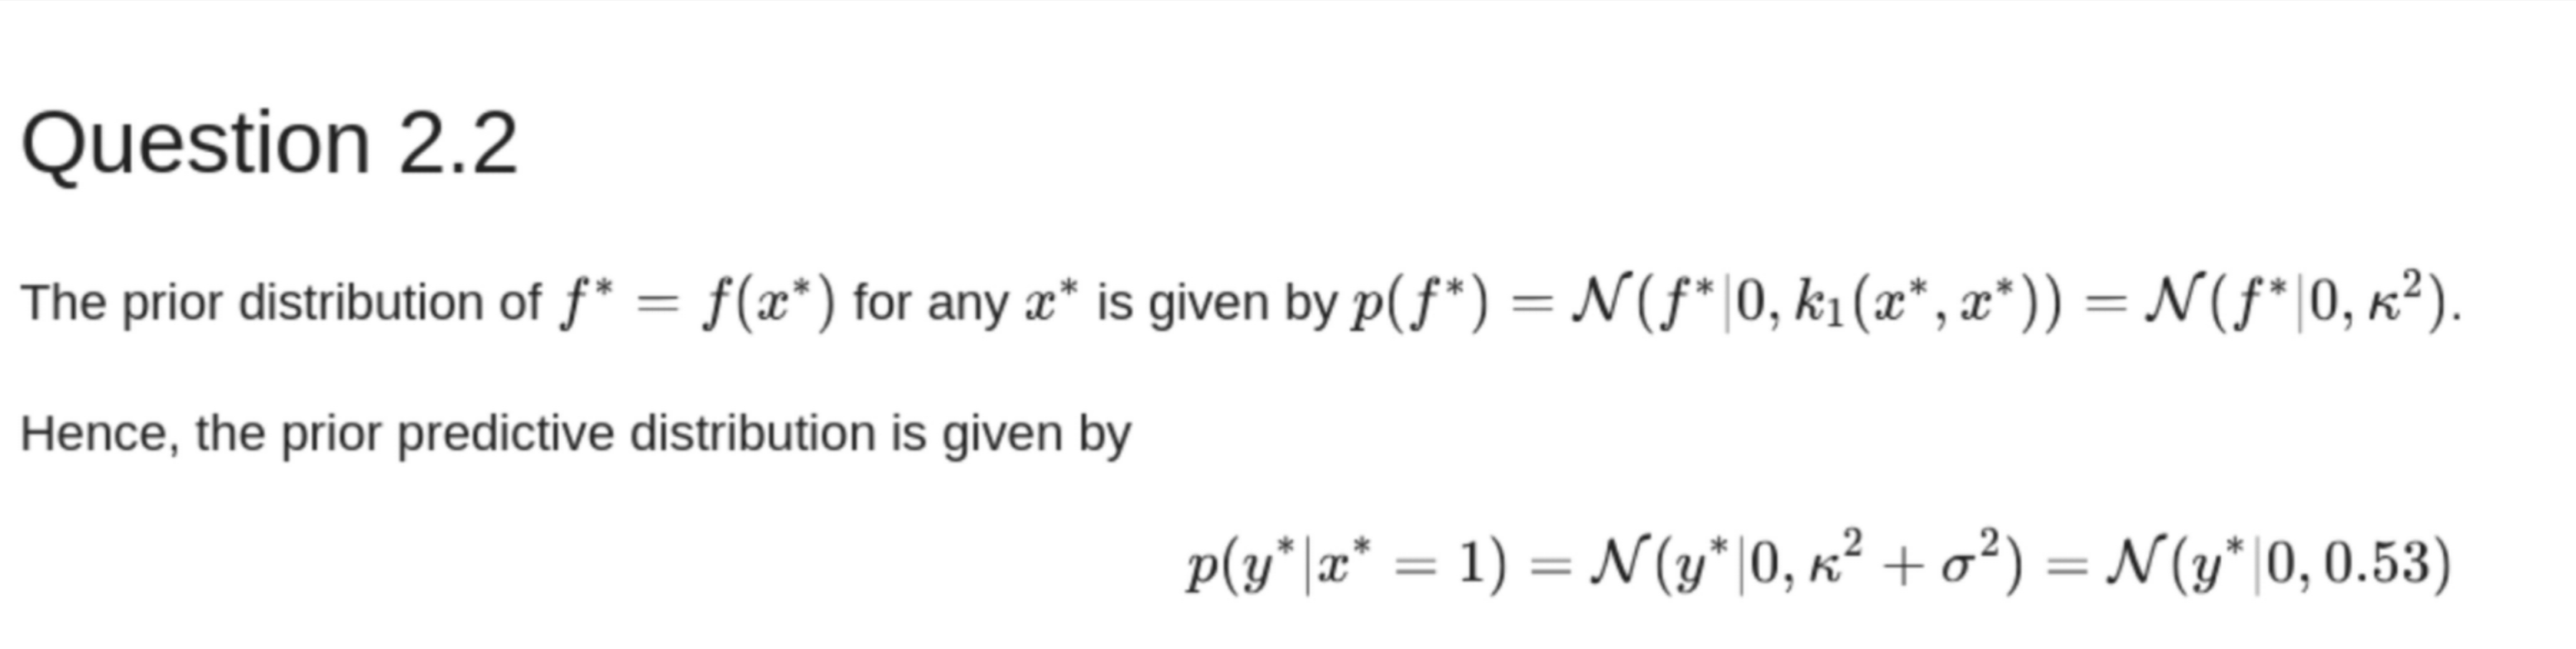

**Gaussian Process Prior and Prior Predictive Distribution**

*Prior over function values*
In GP regression, the first thing we always model is the distribution over the $\textbf{functional values}$, not the observations, which means:
$$
f^* = f(x^*) \sim \mathcal{N}(0, k(x^*, x^*)) = \mathcal{N}(0, \kappa^2)
$$
This is a $\textbf{pure function}$ under the GP prior — $\textbf{no noise yet!}$  

*Observational noise*
$\textbf{Observational noise:}$  
The actual observed output at $x^*$ is not $f^*$; it's:
$$
y^* = f^* + \epsilon, \quad \text{with} \quad \epsilon \sim \mathcal{N}(0, \sigma^2)
$$
Since $f^*$ and $\epsilon$ are independent Gaussians, their sum is also Gaussian:
$$
y^* \sim \mathcal{N}(0, \kappa^2 + \sigma^2)
$$

*Prior predictive distribution*
So the $\textbf{prior predictive}$ over the noisy output is:
$$
p(y^* \mid x^*) = \mathcal{N}(0, \kappa^2 + \sigma^2)
$$



✅ **Why did the teacher focus on $f^*$?**

Because it is cleaner and pedagogically sound to first state the GP prior on the function, then add the noise model separately to get $y^*$.

This two-step process matches the GP regression generative story:

- $f \sim \mathcal{GP}(0, k(x, x'))$ 
- $y_n = f(x_n) + \epsilon_n \quad \text{with noise} \quad \epsilon_n \sim \mathcal{N}(0, \sigma^2)$

So the teacher’s write-up just follows this modeling logic — they calculate:

**First:**

- $p(f^*) = \mathcal{N}(0, \kappa^2)$

**Then:**

- $p(y^*) = \mathcal{N}(0, \kappa^2 + \sigma^2)$  

---

🔁 **In Summary**

- The teacher starts with the GP prior over function values $f^*$ because that’s the foundation of the model.

- Then they add observation noise $\epsilon^*$ to get the final predictive distribution for $y^*$.

- It’s just a clean separation of model components:  
  **first the signal, then the noise.**

### Teachers solution


In [56]:
print(f"p(y^* | x^*=1) = N(y^*| 0, {kappa**2 + sigma**2:3.2f})")

p(y^* | x^*=1) = N(y^*| 0, 0.53)


__________________________

## Question 2.3: Determine the analytical posterior predictive distribution p(y*|y, x* = 227) for y* = y(x*).


In [57]:
x_star = jnp.array([277])

mean_post, var_post = GP_.predict_y(x_star)

print(f"The posterior predictive distribution for p(y*|y, x*=277) = N({mean_post.item():.2f}, {var_post.item():.2f})")

The posterior predictive distribution for p(y*|y, x*=277) = N(0.00, 0.53)


**✅ Intuition**

This question is asking, "Given the observed data $y$  I have seen so far, how does the function behave at a new point $x^* = 227$?"

- The mean tells you the models best guess at $y^*$.
- The variance tells you th moodels uncertanity abotu the guess. Which goes down near training points an stays high away from training points reverting to the prior uncertainty.

**✨ Interpretation**
- if $x^* = 227$ is far from yout training data, the prediction will fall back toward the prior mean (which is 0 in this case) and the variance will be close to $\kappa^2 + \sigma^2$, i.e. the prior uncertainty.
- if $x^* = 227$ is close to your training data, the prediction will be more accurate, with a lower variance.

### Teachers solution

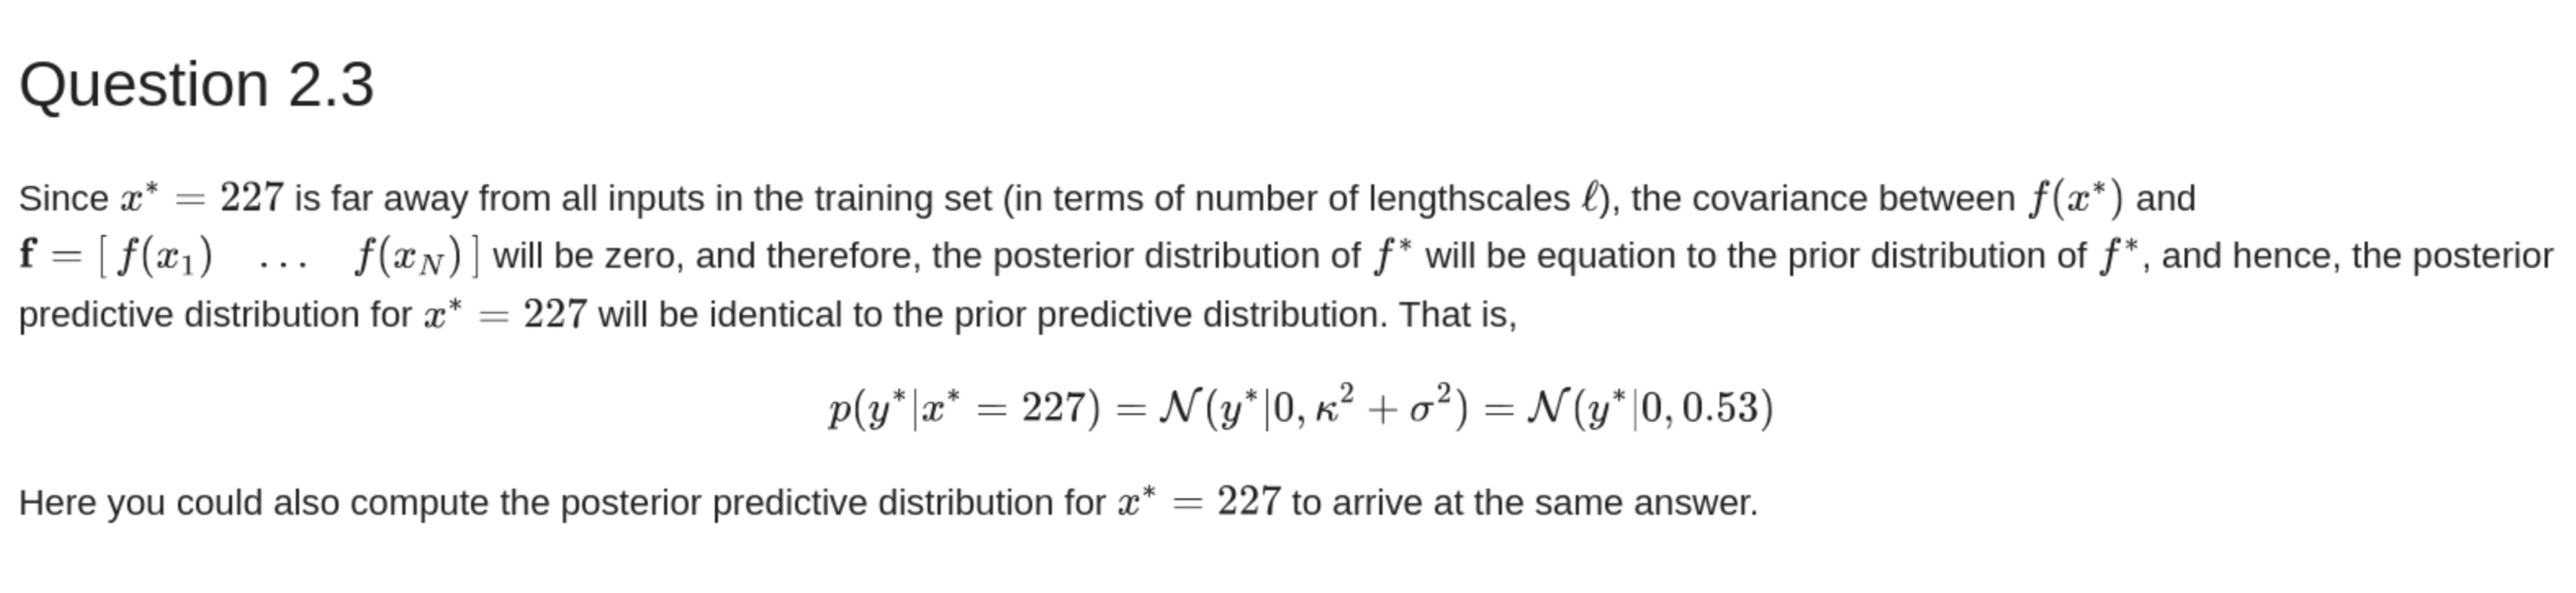

### Question 2.4: Determine the analytical expression for the marginal likelihood p(y|κ, ℓ, σ) and compute the numerical value of log p(y|κ, ℓ, σ).


In [58]:
log_marginal = GP_.log_marginal_likelihood(kappa=kappa, lengthscale=ell, sigma=sigma)

print(f"The value of log marginal marginal likelihood log p(y) = {log_marginal:.2f} ")

The value of log marginal marginal likelihood log p(y) = -6.65 


**🧠 Intuition Behind the Log Marginal Likelihood** 
- **What does the marginal likelihood measure?**

   It measures how well your GP model (with the current hyperparameters) explains the observed data $y$.

- **It answers**:

 “If the function $f$ came from a GP with kernel $k(⋅,⋅;κ,ℓ)$ and noise $σ$, how probable is it that I would observe the actual data $y$ I saw?”

- **What does the value mean**

    We got: $\log p(y) = -6.65$. This means that the **density** assigned to your data **$y$** by the model is: $p(y) = e^{-6.65} \approx 0.0013$. This isn't a probability, but a density. This value is useful for comparing different models or hyperparameters.
     A **higher value** means the model explains the data well.
     A **lower value** means the model does not explain the data well.
     

### Teachers solution 

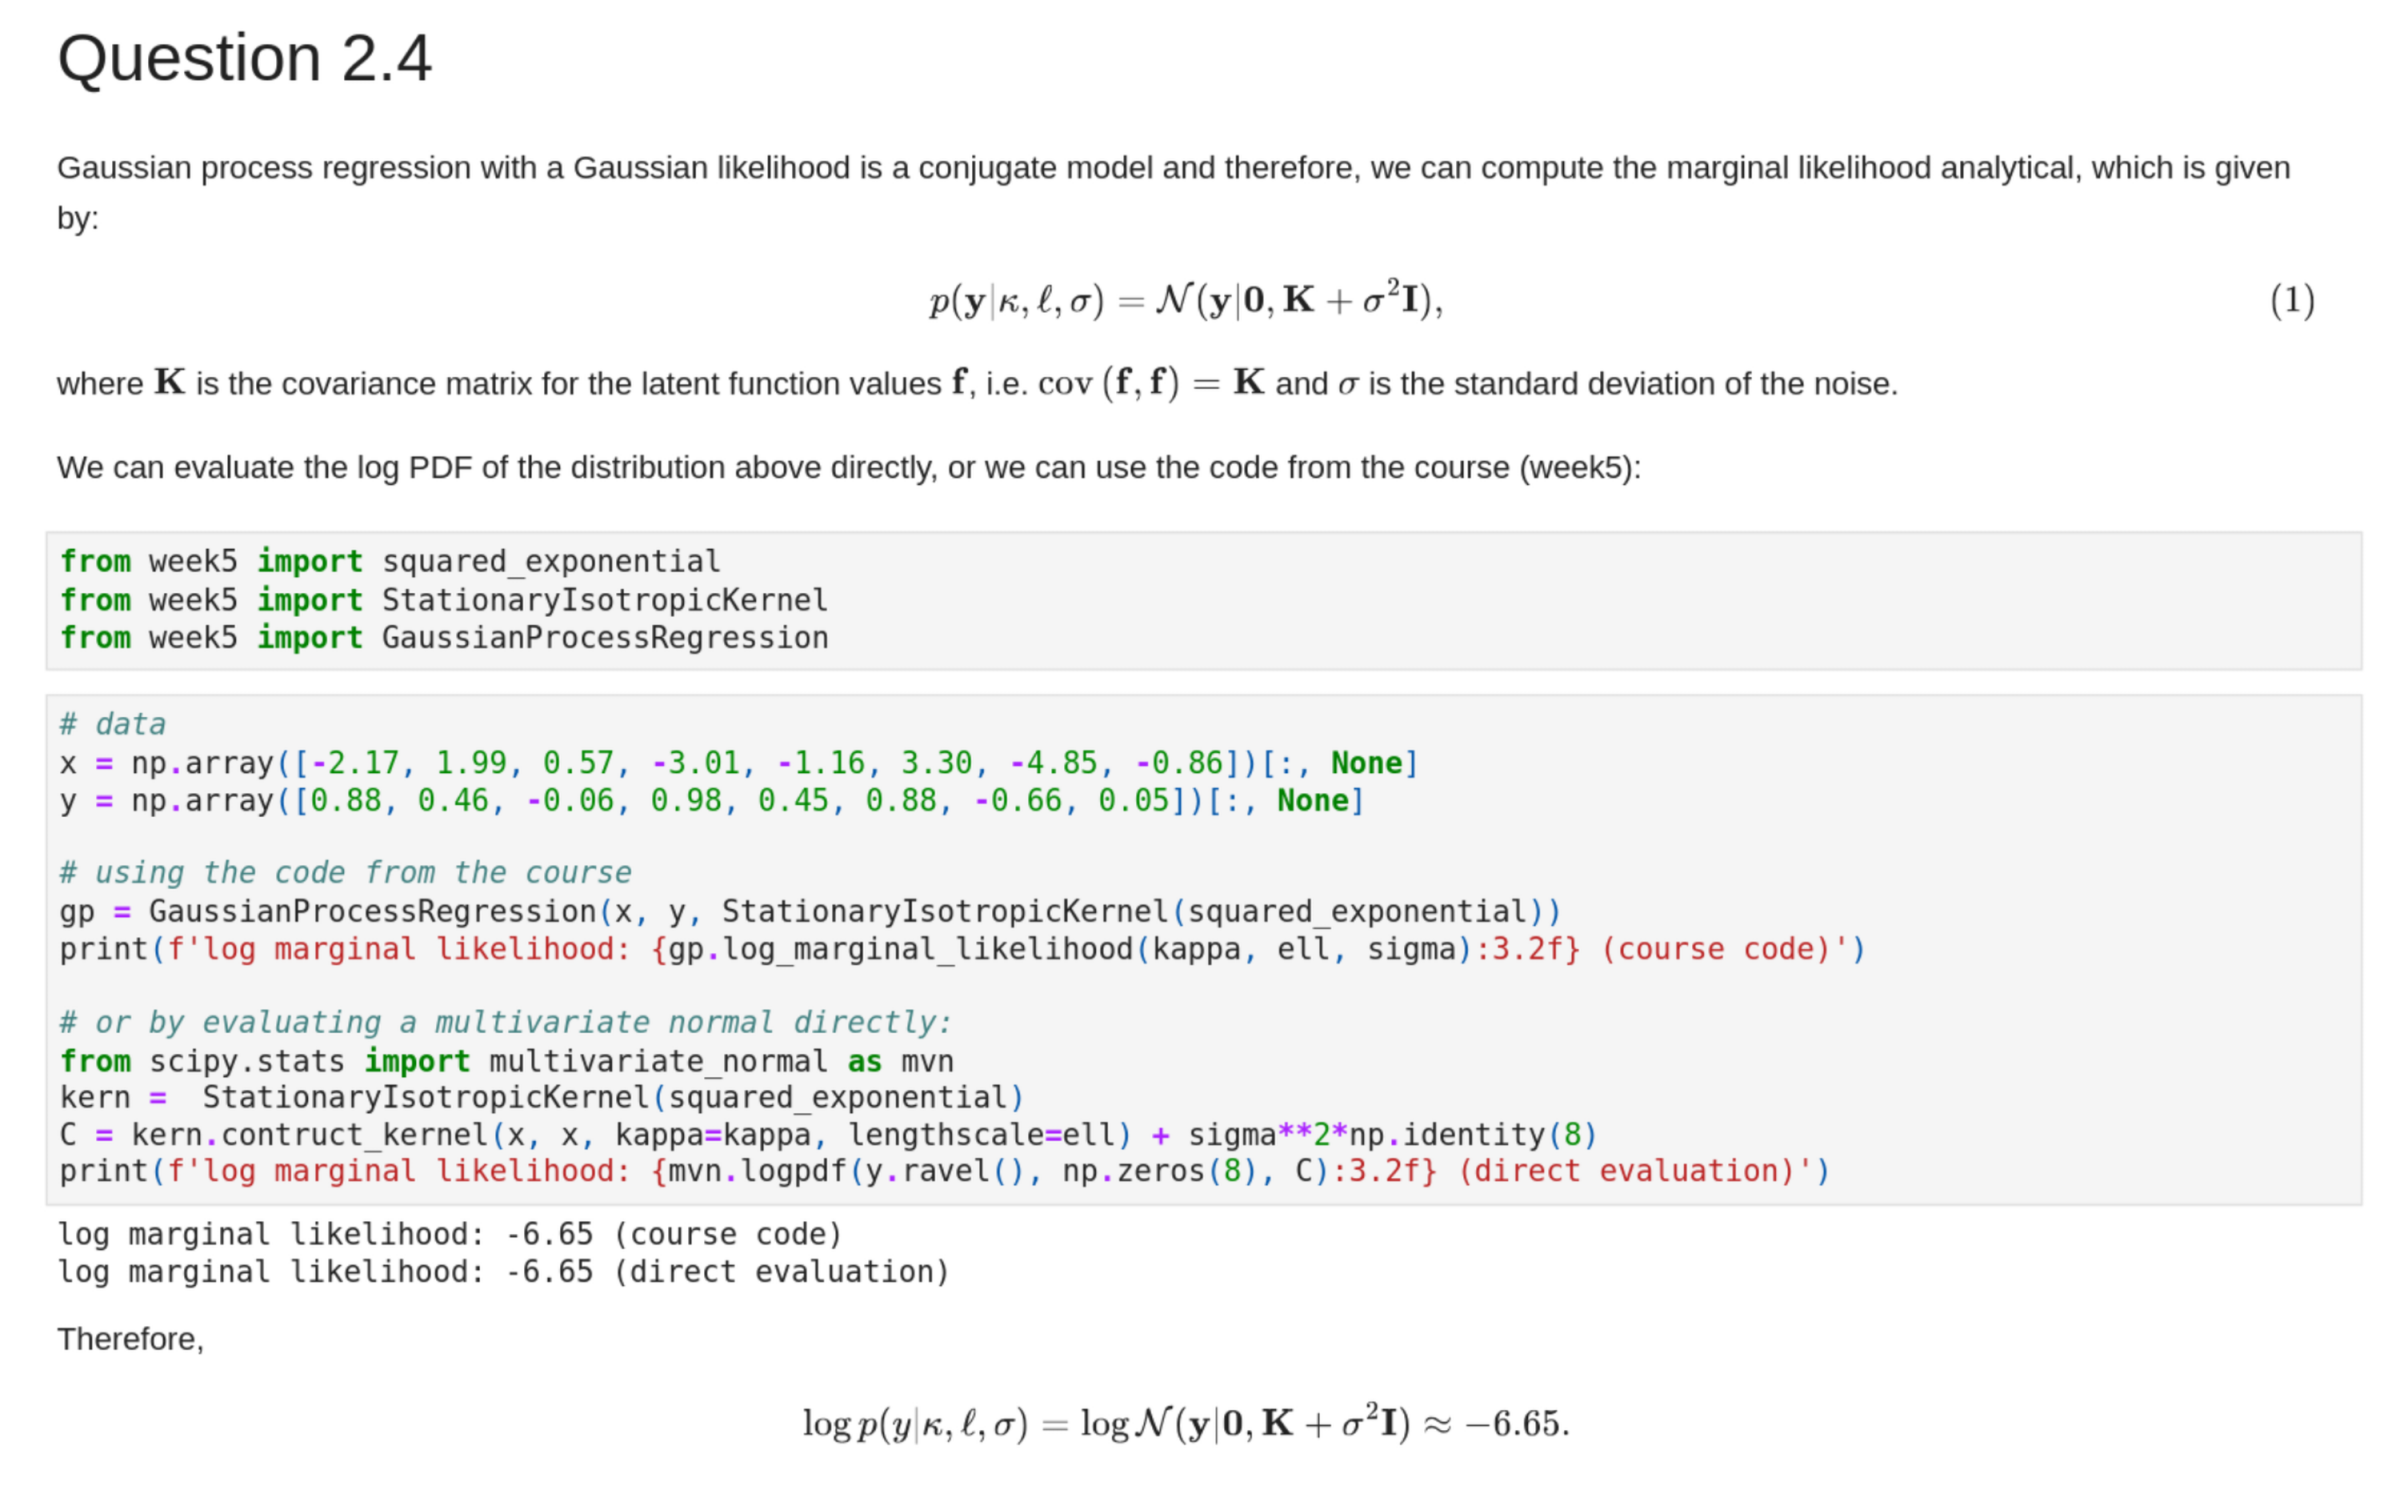

## Question 2.5: Determine the analytical posterior distribution p(f ∗ |y, x∗ = 1) for f ∗ = f (x∗) as well as the analytical posterior predictive distribution for p(y∗ |y, x∗ = 1) for y∗ = y(x∗ ).


In [59]:
x_star = jnp.array([1])

mu_f, var_f = GP_.predict_f(Xstar=x_star)
print(f"The analytical posterior distribution p(f*|y, x*=1) = N(f*|{mu_f.item():.2f}, {var_f.item():.2f})")
mu_y, var_y = GP_.predict_y(Xstar=x_star)
print(f"The analytical posterior distribution p(y*|y, x*=1) = N(f*|{mu_y.item():.2f}, {var_y.item():.2f})")

The analytical posterior distribution p(f*|y, x*=1) = N(f*|0.07, 0.14)
The analytical posterior distribution p(y*|y, x*=1) = N(f*|0.07, 0.18)


## Question 2.7: Compute the prior covariance between $f = [f (x1), f (x2 ), . . . , f (x8)]$ and $f^* = f (x^*)$ for $x^* = −1$ for $c_1 = c_2 = 1$ and $\ell = \sqrt{1.2}$.

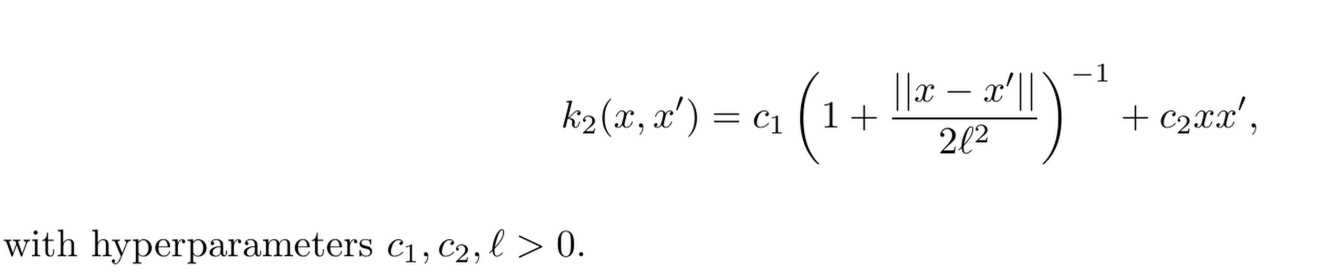

In [60]:
def squared_exponential_2(x1, x2, c1, c2, lengthscale):
    return  (( 1 + jnp.abs(x1 - x2) / (2 * lengthscale**2))**(-1)) + x1 * x2 

In [61]:
x_star = jnp.array([-1]).reshape(-1)
kernel2 = squared_exponential_2(x1=x, x2=x_star, c1=1, c2=1, lengthscale=jnp.sqrt(1/2))

# Print the kernel values with 2 decimal places
print(jnp.round(kernel2, 2))

[[ 2.63]
 [-1.74]
 [-0.18]
 [ 3.34]
 [ 2.02]
 [-3.11]
 [ 5.06]
 [ 1.74]]


### Teacher solution 

In [62]:
import numpy as np

# Define data
x = np.array([-2.17, 1.99, 0.57, -3.01, -1.16, 3.30, -4.85, -0.86])[:, None]



k2 = lambda x, xprime: 1./(1 + np.abs(x - xprime)) + x * xprime

xstar = np.array(-1)
for xn in x:
    print(f'{np.array2string(k2(xn, xstar), precision=2)}', end=', ')



[2.63], [-1.74], [-0.18], [3.34], [2.02], [-3.11], [5.06], [1.74], 

# Part 3 

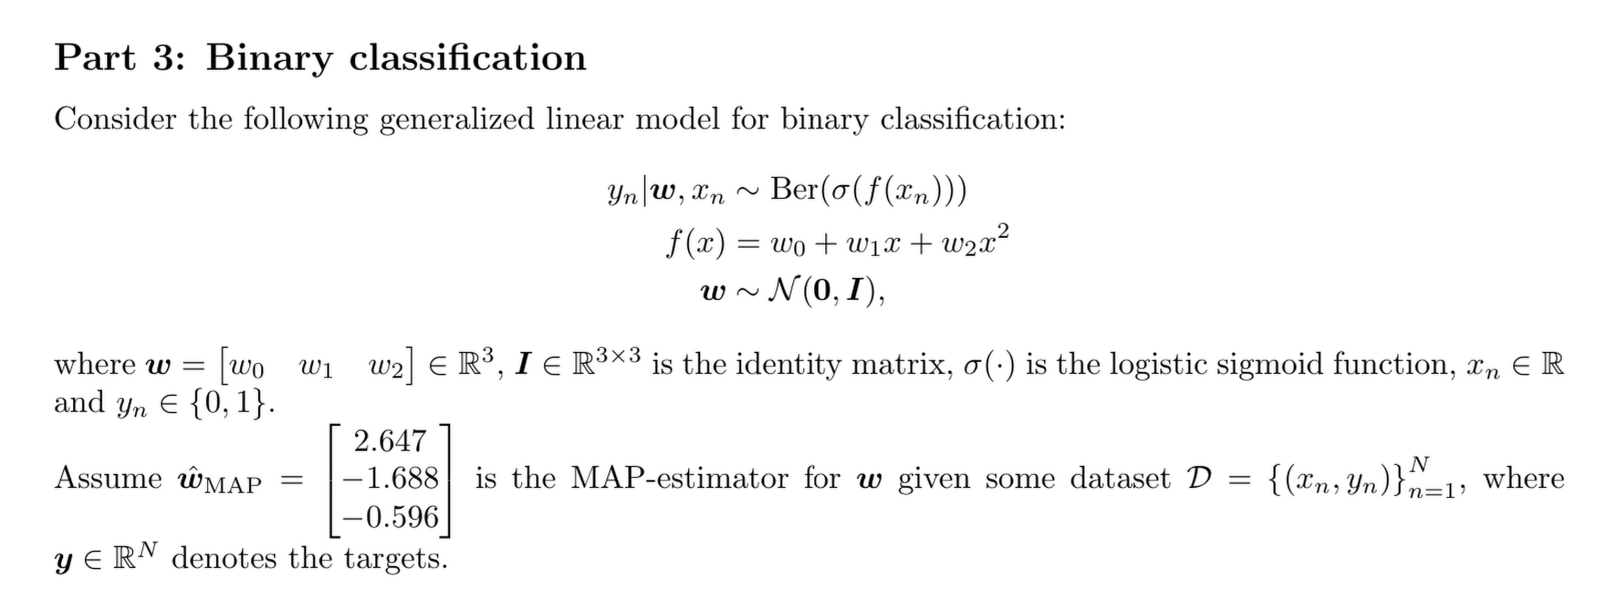

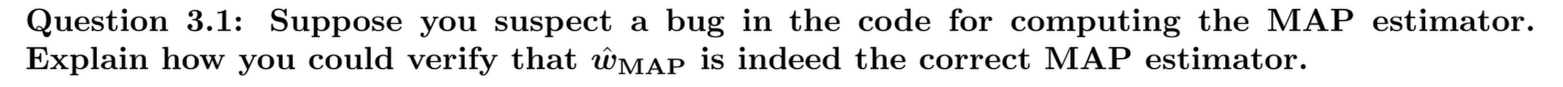

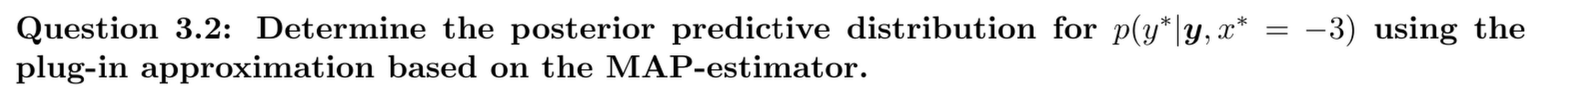

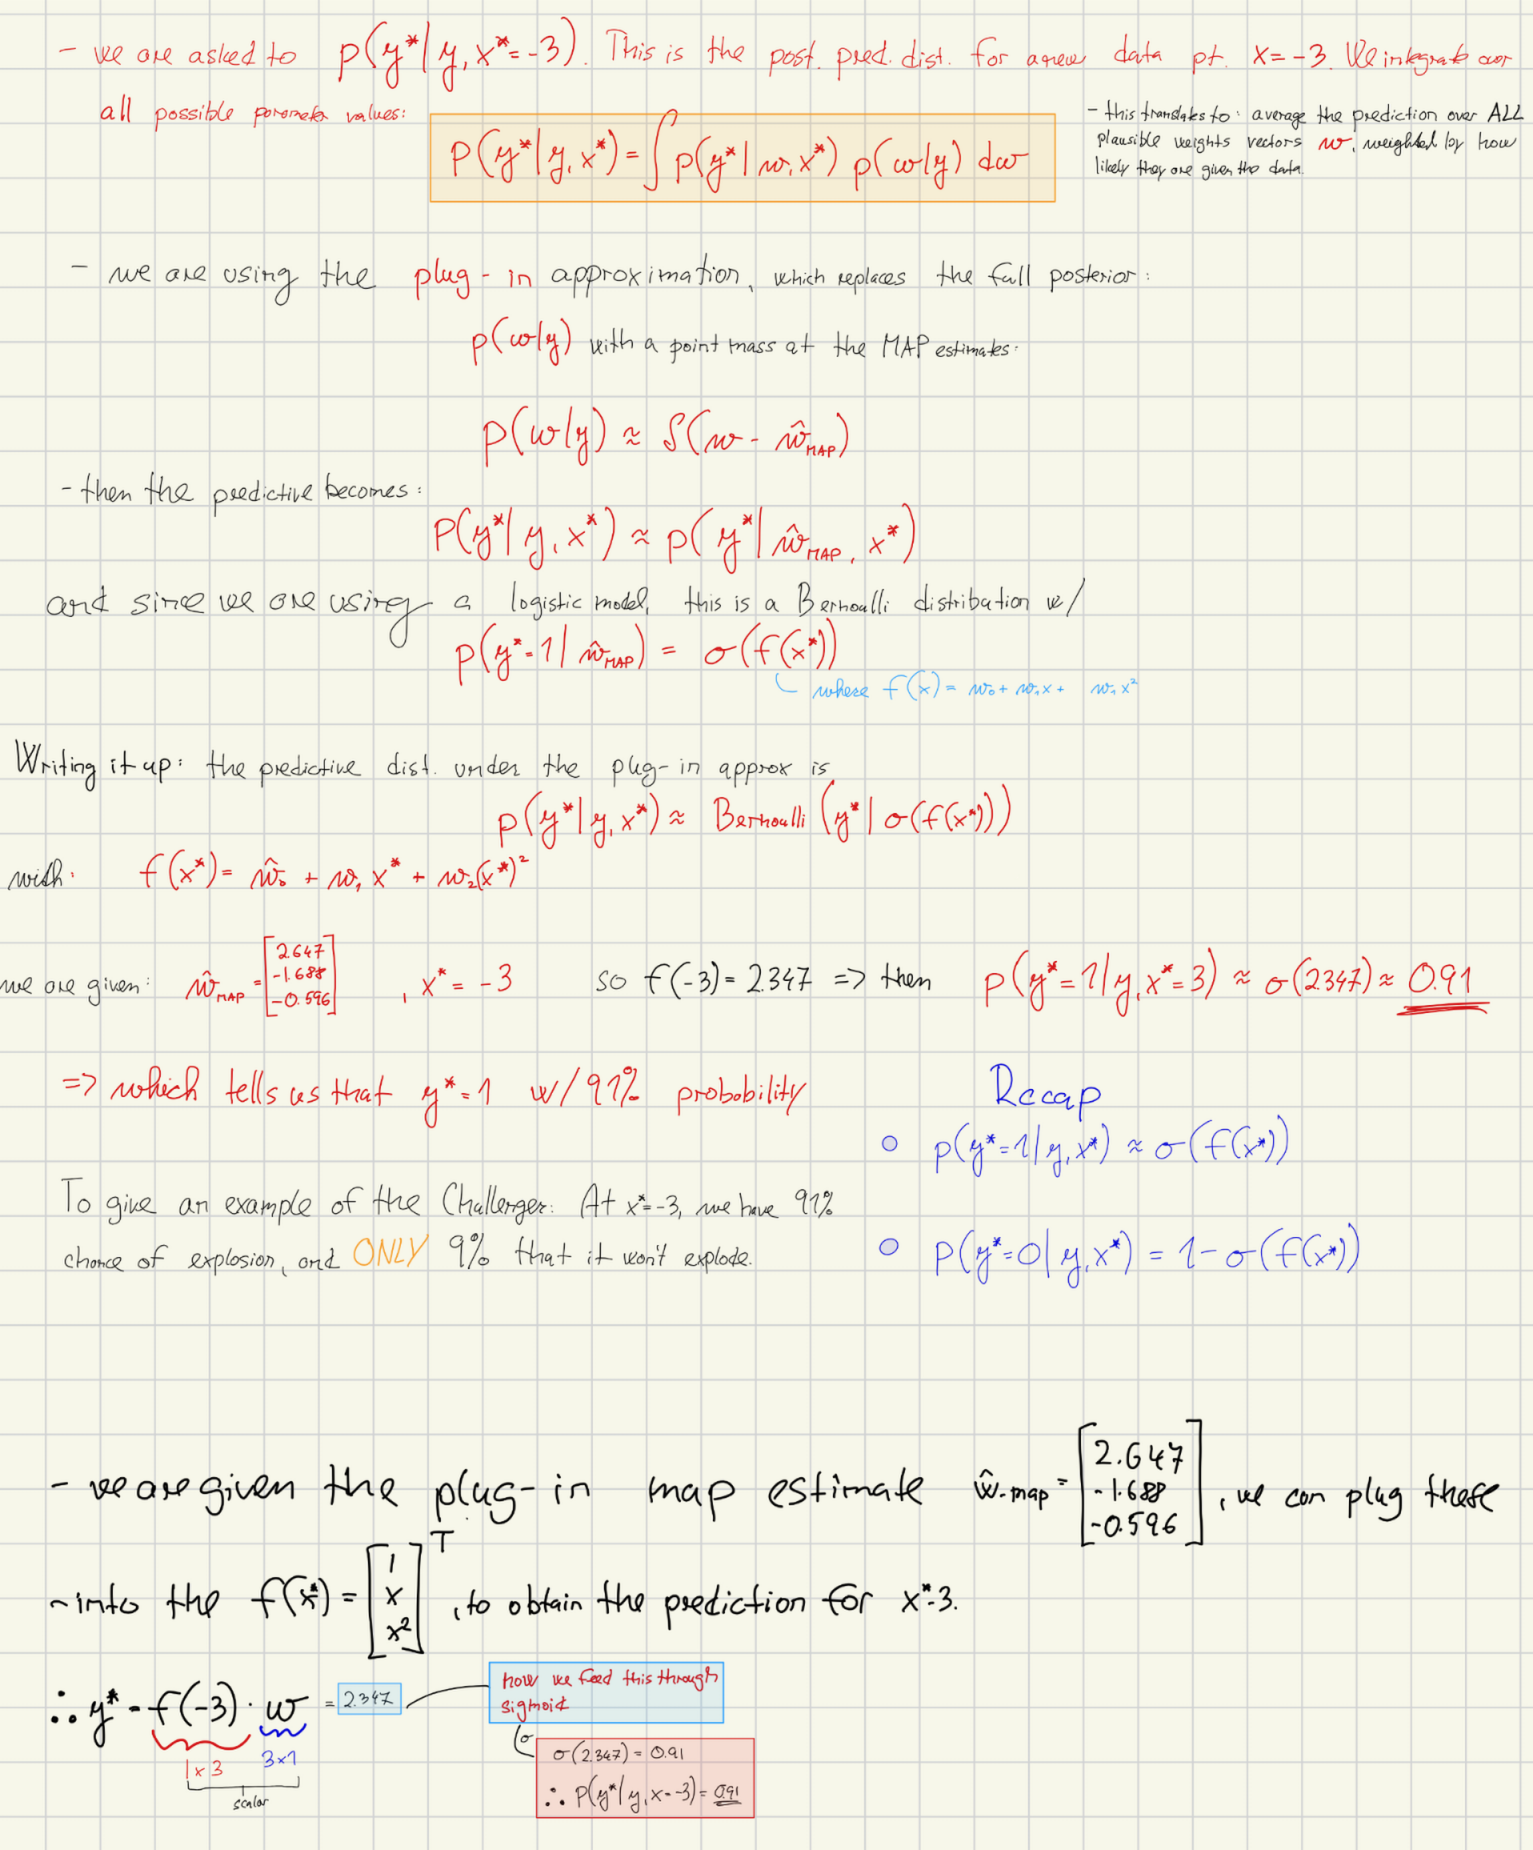


In [63]:
# 
w_map = jnp.array([2.647, -1.688, -0.596]).reshape(-1, 1)

f_x = lambda x, w: w[0] + w[1] * x + w[2] * x**2

In [64]:
post_pred = f_x(x=-3, w=w_map)

In [65]:
def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

In [66]:
print(sigmoid(post_pred))

[0.91269548]


#### Vectorized solution:  

In [71]:
def design_matrix(x):
    """
    Φ(x) = [1, x, x²]      ← quadratic trend basis
    Feel free to uncomment seasonal cosine terms etc.
    """
    return jnp.column_stack((jnp.ones(len(x)), x, x**2)) 

x_star = jnp.array([-3]).reshape(-1, 1)


f_x = design_matrix(x_star)
print(f"Shape of the design matrix {f_x.shape}")
print(f"Design_matrix = {f_x}")
print(f"Shape of w_map = {w_map.shape}")
print(f"w_map = {w_map}")
y_star_map = f_x @ w_map


print(y_star_map)

print(sigmoid((y_star_map)))

Shape of the design matrix (1, 3)
Design_matrix = [[ 1. -3.  9.]]
Shape of w_map = (3, 1)
w_map = [[ 2.647]
 [-1.688]
 [-0.596]]
[[2.347]]
[[0.91269548]]


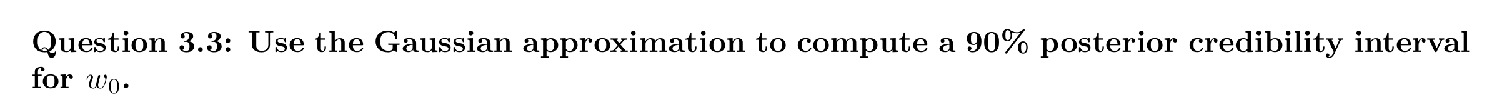

In [72]:
import jax

mu = w_map[0]
sigma = jnp.sqrt(3)
key = jax.random.PRNGKey(42)

samples = mu + sigma * jax.random.normal(key, shape=(10**6,))


interval = jnp.percentile(samples, jnp.array([5, 95]))
print(f'95% credibility interval: [{interval[0]:.2f}, {interval[1]:.2f}]\t(estimated using sampling)')


95% credibility interval: [-0.20, 5.49]	(estimated using sampling)


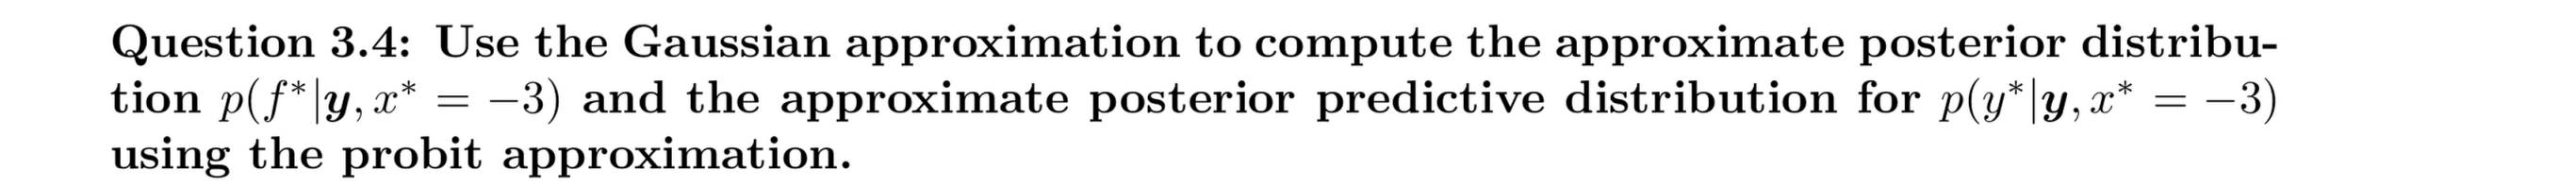

In [73]:
#f_x = lambda x, w: w[0] + w[1] * x + w[2] * x**2

S = jnp.array([
    [3.0, -0.39, -0.3],
    [-0.39, 1.55, 0.37], 
    [-0.3, 0.37, 0.14]
    ])
print(f"Shape of w_map = {w_map.shape}")
#print(f"Shape of x_star = {f_x.shape}")


posterior_f_mean = w_map.T @ f_x.T
print(f"Posterior mean {posterior_f_mean}")

posterior_f_variance = f_x @ S @ f_x.T
print(f"Posterior variance {posterior_f_variance}")

Shape of w_map = (3, 1)
Posterior mean [[2.347]]
Posterior variance [[5.25]]


In [74]:
from scipy.stats import norm as norm_dist

probit = lambda x: norm_dist.cdf(x)

y_star = lambda m, v: probit(m/jnp.sqrt(8/jnp.pi + v))


print(y_star(posterior_f_mean, posterior_f_variance))

[[0.79970011]]


In [75]:
print(sigmoid(posterior_f_mean))

[[0.91269548]]


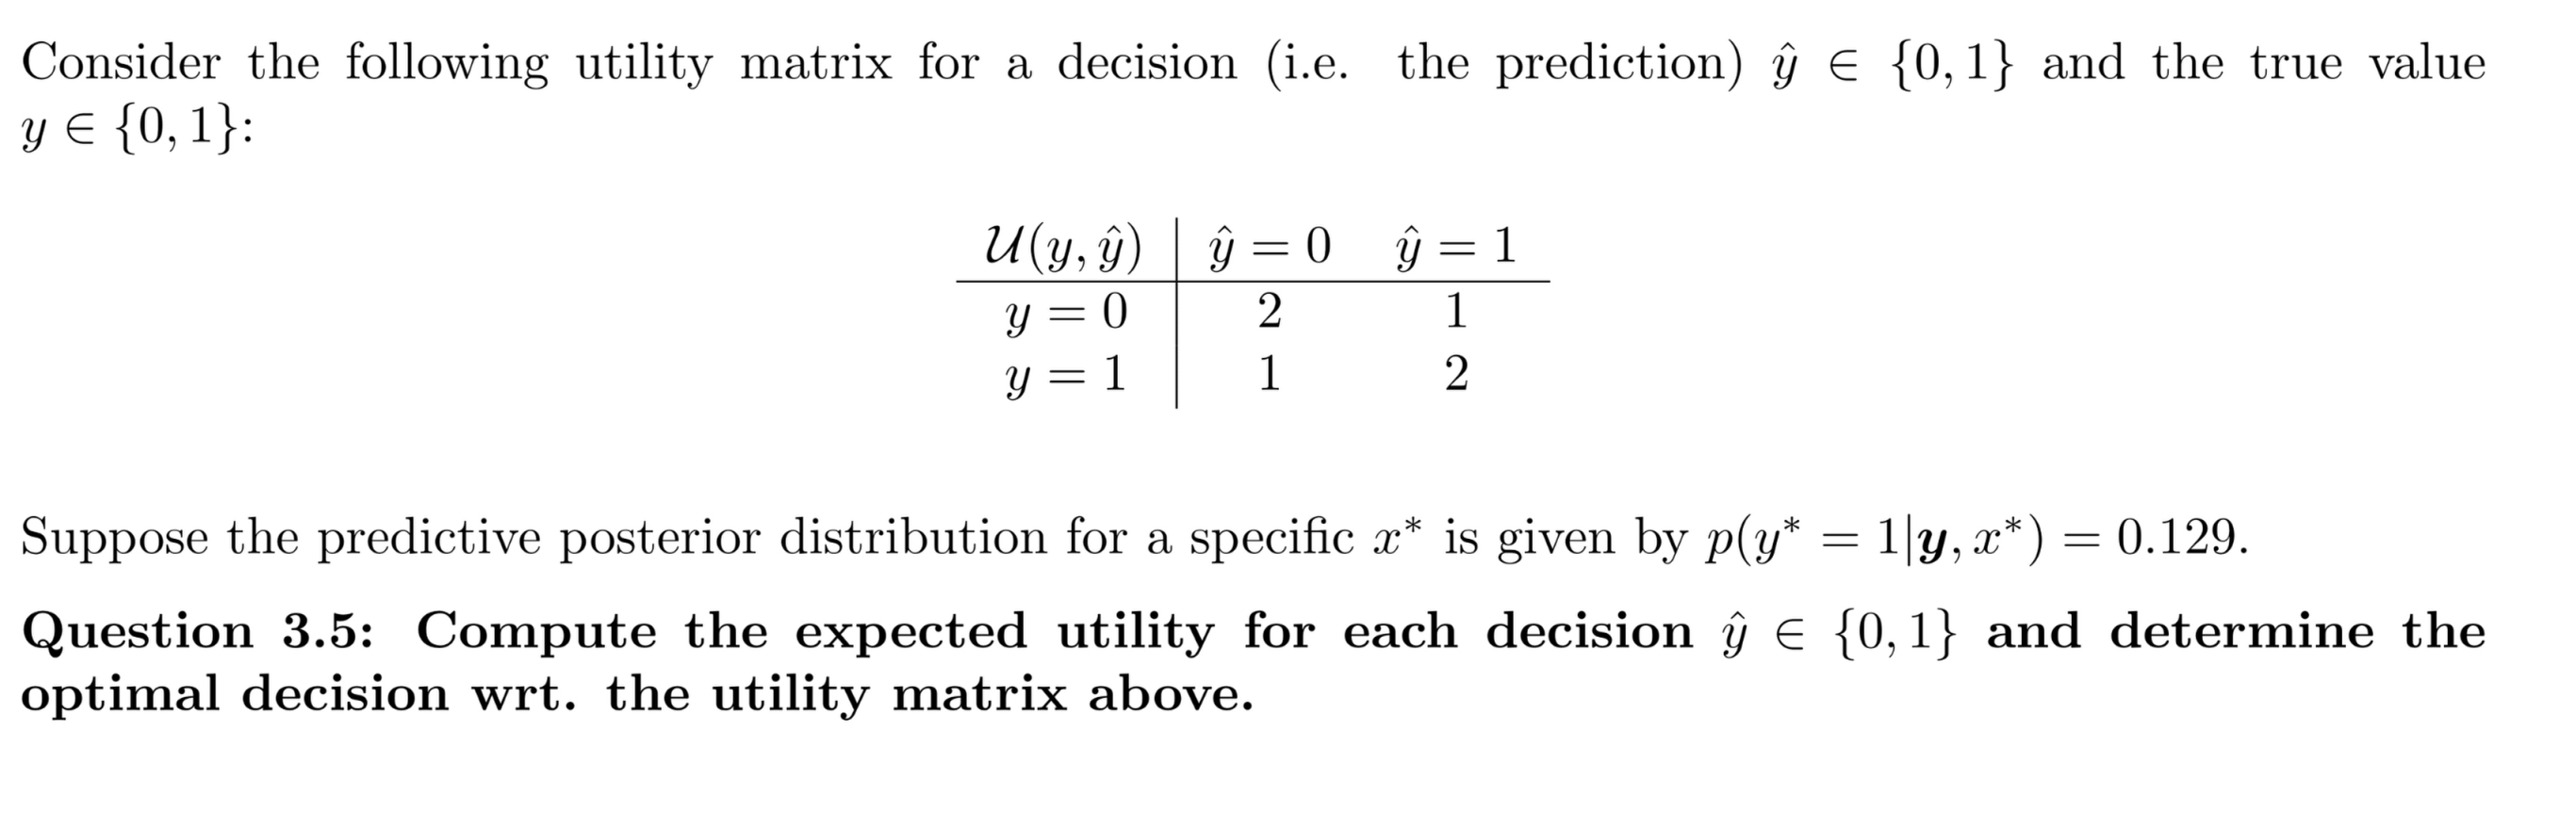

In [76]:
U = jnp.array([[2, 1], 
           [1, 2]])
p_hat = jnp.array([0.129, 1 - 0.129]) 

print(compute_expected_utility(U, p_hat))

NameError: name 'compute_expected_utility' is not defined

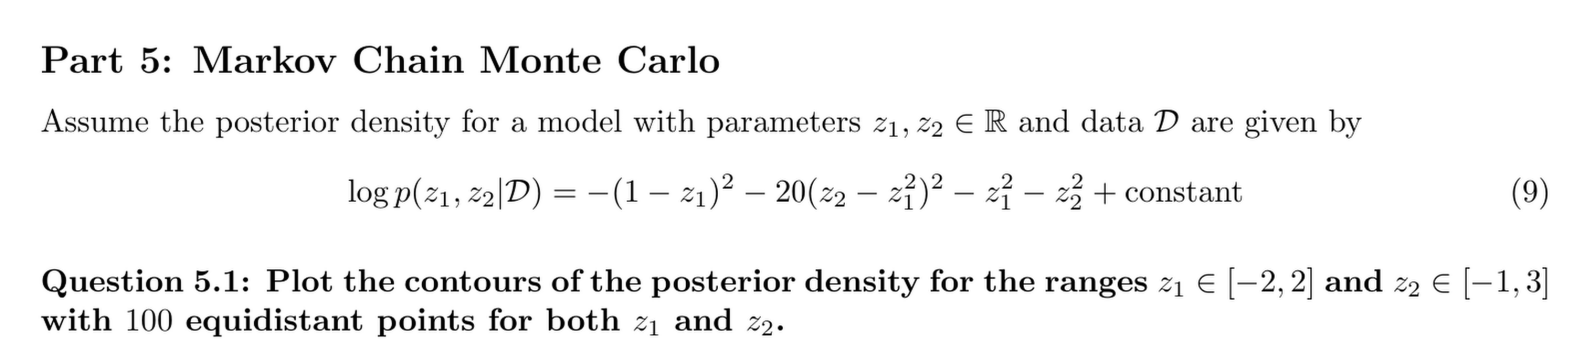

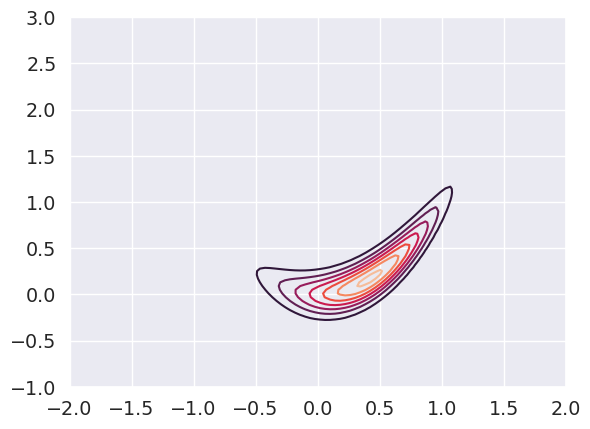

In [77]:
def log_joint(z_1, z_2): 
    return - (1 - z_1)**2 - 20 * (z_2 - z_1**2)**2 - z_1**2 - z_2**2 
    

v_func = jnp.vectorize(log_joint)

x, y = jnp.meshgrid(jnp.linspace(-2, 2, 100),
                     jnp.linspace(-1, 3, 100))

fig, ax = plt.subplots(1)
ax.contour(x, y, jnp.exp(v_func(x, y)))
plt.show()

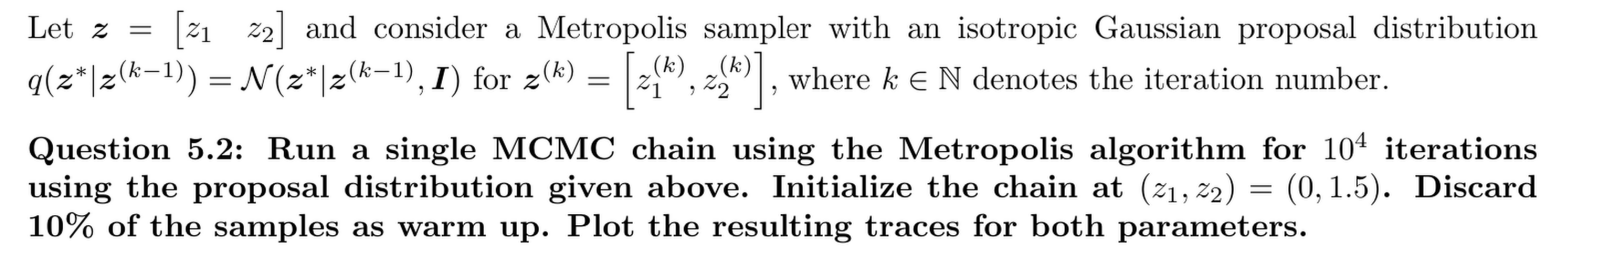

In [78]:
num_alpha, num_beta = 90, 100
alphas = jnp.linspace(-4, 4, num_alpha)  # Shape: (90,) - intercept parameter range
betas = jnp.linspace(-4, 4, num_beta)    # Shape: (100,) - slope parameter range

%matplotlib inline
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np
from jax import random
import seaborn as snb

# distributions
from scipy.stats import norm
from scipy.stats import multivariate_normal as mvn
from scipy.stats import poisson

# for plotting and visualization
from exercise8 import plot_predictions
from exercise8 import eval_density_grid

# style stuff
snb.set_style('darkgrid')
snb.set(font_scale=1.25)

import plotly.express as px



In [81]:
from jax import random
# Define the log-target density: log of a Gaussian N(x | mean=1, var=3)
# Input: x ∈ ℝ¹ (shape: (1,))
# Output: scalar log-density value (float)

num_parameters = 2
tau = 1
N_samples = 10**4
theta_init = jnp.array([0, 1.5])

def log_joint(z):
    z_1 = z[0]
    z_2 = z[1] 
    return - (1 - z_1)**2 - 20 * (z_2 - z_1**2)**2 - z_1**2 - z_2**2 

# Run the Metropolis-Hastings sampler to generate samples from the target distribution
# Arguments:
# - p_target       : log-density function
# - num_params     : 1 parameter (scalar x)
# - tau            : standard deviation of the proposal (τ = 2.0)
# - num_iter       : number of MCMC steps (20,000 samples)
# - theta_init     : initial point (x₀ = 0.0), shape = (1,)
# Output:
# - thetas         : array of samples from Markov chain, shape = (20001, 1)


thetas = MH.metropolis(log_target=log_joint, num_params=num_parameters, tau=tau, num_iter=N_samples, theta_init=theta_init, seed=1)

Acceptance ratio: 0.09
10001
(10001, 2)


Text(0.5, 0.01, 'Iterations')

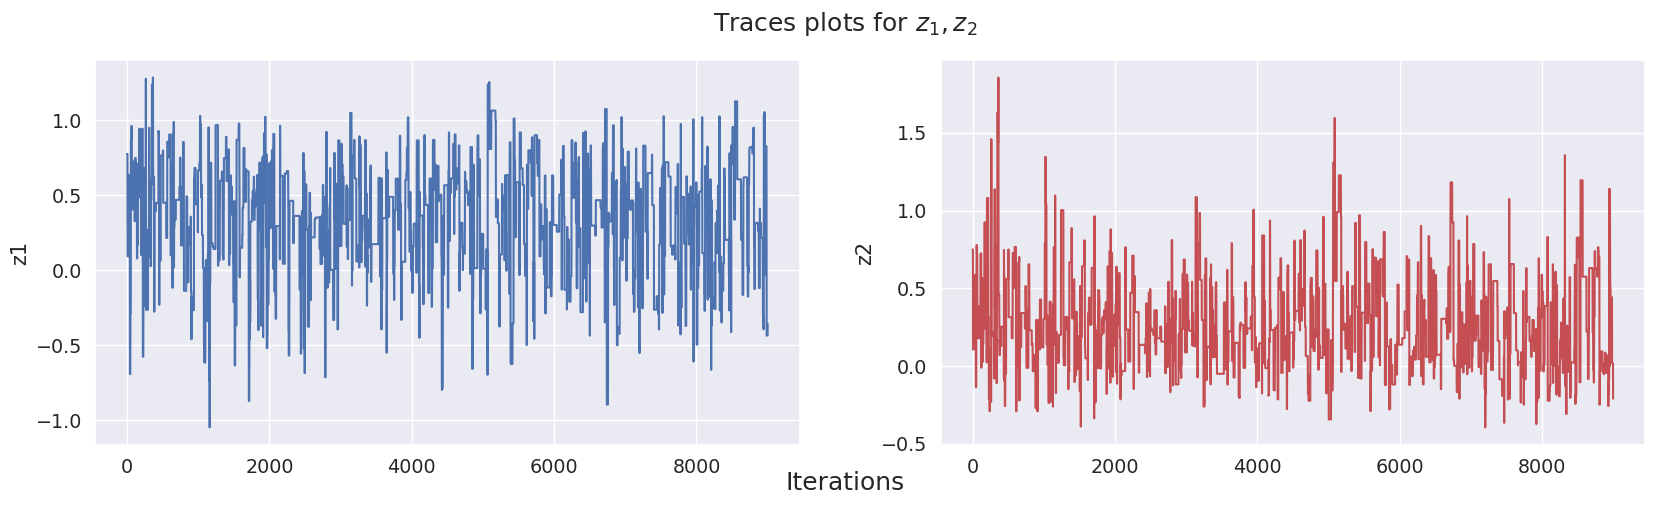

In [99]:
discard = 0.1


warm_up = int(discard*10**4)


z1 = thetas[warm_up:, 0]
z2 = thetas[warm_up:, 1]


fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Trace plot
axes[0].plot(z1, label='Before warm-up')
axes[0].set_ylabel('z1')
axes[1].plot(z2, label='Before warm-up', c='r')
axes[1].set_ylabel('z2')
fig.suptitle('Traces plots for $z_1, z_2$')
# Common x-axis label
fig.supxlabel('Iterations')  # Set your desired label here

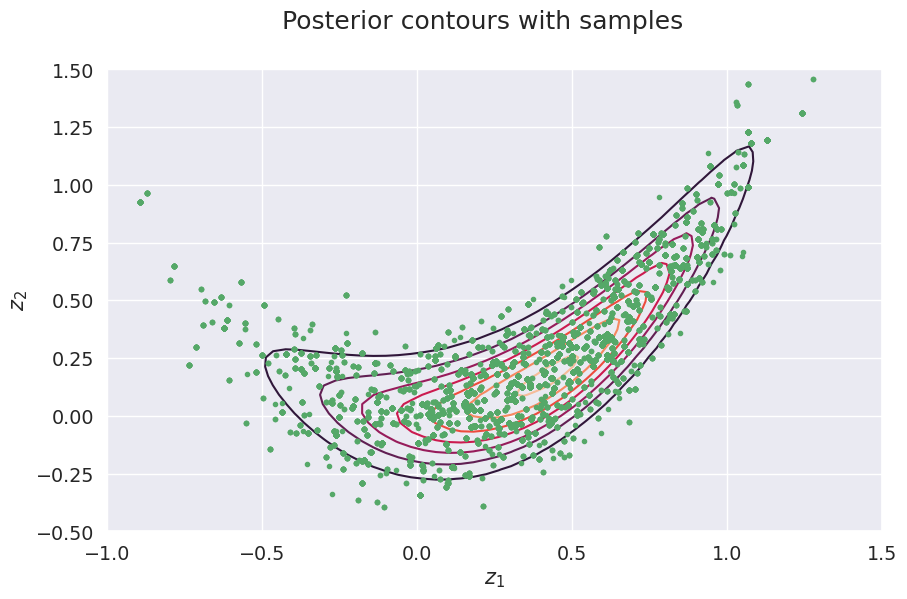

In [106]:
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.contour(x, y, jnp.exp(v_func(x, y)))
ax.plot(z1, z2, 'g.')
ax.set_ylim(-0.5, 1.5)
ax.set_xlim(-1.0, 1.5)
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
fig.suptitle('Posterior contours with samples')
plt.show()

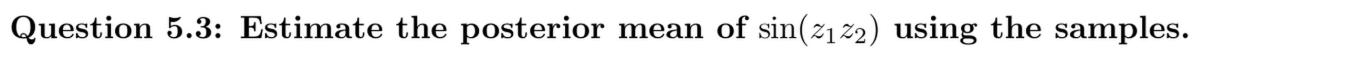

In [ ]:
print(f"Posterior mean of sin(z1z2) = {jnp.mean(jnp.sin(z1 * z2)):.2f}")

Posterior mean of sin(z1z2) = 0.15


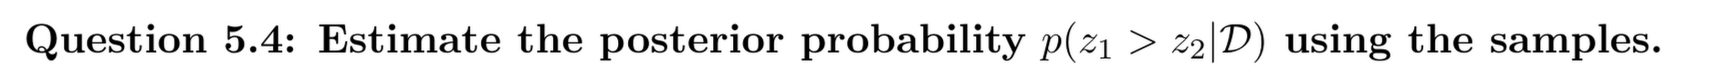

In [ ]:
print(f"Posterior mean of p(z1 > z2 |D) = {jnp.mean(z1 > z2):.2f}")

Posterior mean of p(z1 > z2 |D) = 0.75
